# Physics-Informed Neural Network (PINN) for Equation Discovery

This notebook demonstrates a more advanced PINN approach for equation discovery, where the structure of the differential equation itself is unknown.

## 1. Problem: Discovering an Unknown ODE

We assume a system is governed by an unknown first-order Ordinary Differential Equation (ODE) of the form:
$$ \frac{dy}{dt} = f(y) $$
Here, $f(y)$ is an unknown function representing the underlying dynamics. The goal is to discover the structure and parameters of $f(y)$ directly from data.

### The Two-Network Approach

We solve this using two separate neural networks:

1.  **Solution Network (`NN_y`):** This network approximates the solution to the ODE. It takes time `t` as input and outputs the predicted state `y_pred(t)`.
    $$ y_{pred}(t) = NN_y(t) $$

2.  **Dynamics Network (`NN_f`):** This network approximates the unknown function `f(y)`. It takes the state `y` as input and learns the governing dynamics.
    $$ f_{pred}(y) = NN_f(y) $$

### The Physics-Informed Loss

The core of the discovery process is a loss function that enforces the relationship $\frac{dy}{dt} = f(y)$.

- We compute the derivative of the Solution Network's output, $\frac{d(y_{pred})}{dt}$, using automatic differentiation.
- We evaluate the Dynamics Network at the output of the Solution Network, $NN_f(y_{pred})$.

The physics loss minimizes the difference between these two quantities, forcing the derivative of our solution to match the output of our dynamics network:
$$ \text{Loss}_{physics} = \left\| \frac{d(y_{pred})}{dt} - f_{pred}(y_{pred}) \right\|^2 = \left\| \frac{d(NN_y)}{dt} - NN_f(NN_y(t)) \right\|^2 $$

The total loss combines this with a standard data loss to ensure the solution network fits the measurements:
$$ \text{Loss}_{total} = \text{Loss}_{data} + \lambda \cdot \text{Loss}_{physics} $$

## 2. Implementation (PyTorch)

In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Define the True ODE and Generate Synthetic Data

For this example, we will generate data from the ODE $\frac{dy}{dt} = -0.5y$. The goal is for the Dynamics Network `NN_f` to learn this linear relationship without being told.

In [17]:
# True ODE: dy/dt = -k * y
k_true = 0.5

def true_solution(t, k):
    return np.exp(-k * t) # Assuming y(0) = 1

def true_dynamics(y, k):
    return -k * y

# Generate synthetic data
t_data = torch.linspace(0, 5, 50).view(-1, 1)
y_data = torch.tensor(true_solution(t_data.numpy(), k_true), dtype=torch.float32)
# Add some noise
y_data += 0.05 * torch.randn_like(y_data)

### Define the Neural Networks

In [18]:
# NN_y: Approximates the solution y(t)
class SolutionNetwork(nn.Module):
    def __init__(self):
        super(SolutionNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, t):
        return self.net(t)

# NN_f: Approximates the dynamics f(y)
class DynamicsNetwork(nn.Module):
    def __init__(self):
        super(DynamicsNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, y):
        return self.net(y)

# The main PINN model that holds both networks
class DiscoveryPINN(nn.Module):
    def __init__(self):
        super(DiscoveryPINN, self).__init__()
        self.net_y = SolutionNetwork()
        self.net_f = DynamicsNetwork()

    def physics_loss(self, t_physics):
        t_physics.requires_grad_(True)
        
        # Predict y(t) using the solution network
        y_pred = self.net_y(t_physics)
        
        # Compute dy/dt using automatic differentiation
        dy_dt = torch.autograd.grad(
            y_pred, t_physics,
            grad_outputs=torch.ones_like(y_pred),
            create_graph=True
        )[0]
        
        # Predict f(y) using the dynamics network
        f_y_pred = self.net_f(y_pred)
        
        # The residual is the difference between dy/dt and f(y)
        pde_residual = dy_dt - f_y_pred
        
        return torch.mean(pde_residual**2)

### Training Loop

In [19]:
pinn_model = DiscoveryPINN()
# The optimizer needs to know about the parameters of BOTH networks
optimizer = torch.optim.Adam(pinn_model.parameters(), lr=0.001)
epochs = 10000

# Collocation points for physics loss
t_physics = torch.linspace(0, 5, 100).view(-1, 1)

for epoch in range(epochs):
    optimizer.zero_grad()

    # Data loss
    y_pred_data = pinn_model.net_y(t_data)
    loss_data = torch.mean((y_pred_data - y_data)**2)

    # Physics loss
    loss_physics = pinn_model.physics_loss(t_physics)

    # Total loss (weighted sum)
    total_loss = loss_data + 100*loss_physics

    total_loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Total Loss: {total_loss.item():.4f}, '
              f'Data Loss: {loss_data.item():.4f}, Physics Loss: {loss_physics.item():.4f}')

Epoch 1000/10000, Total Loss: 0.0036, Data Loss: 0.0035, Physics Loss: 0.0000
Epoch 2000/10000, Total Loss: 0.0031, Data Loss: 0.0031, Physics Loss: 0.0000
Epoch 3000/10000, Total Loss: 0.0077, Data Loss: 0.0031, Physics Loss: 0.0000
Epoch 4000/10000, Total Loss: 0.0028, Data Loss: 0.0028, Physics Loss: 0.0000
Epoch 5000/10000, Total Loss: 0.0029, Data Loss: 0.0029, Physics Loss: 0.0000
Epoch 6000/10000, Total Loss: 0.0027, Data Loss: 0.0027, Physics Loss: 0.0000
Epoch 7000/10000, Total Loss: 0.0027, Data Loss: 0.0027, Physics Loss: 0.0000
Epoch 8000/10000, Total Loss: 0.0027, Data Loss: 0.0027, Physics Loss: 0.0000
Epoch 9000/10000, Total Loss: 0.0027, Data Loss: 0.0027, Physics Loss: 0.0000
Epoch 10000/10000, Total Loss: 0.0027, Data Loss: 0.0027, Physics Loss: 0.0000


### Visualization

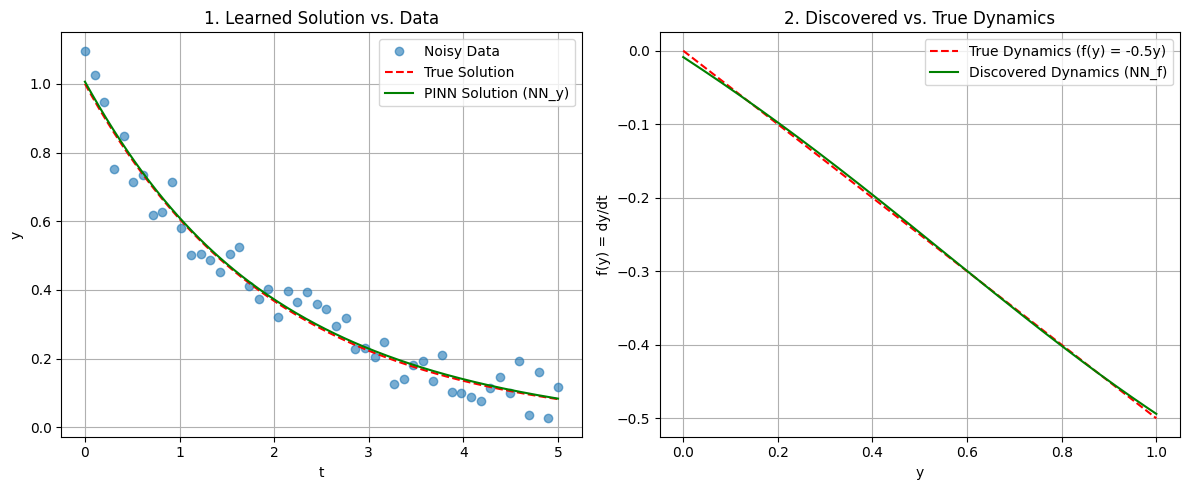

In [20]:
# 1. Plot the learned solution vs. the data
t_plot = torch.linspace(0, 5, 200).view(-1, 1)
with torch.no_grad():
    y_pinn_pred = pinn_model.net_y(t_plot).numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_data.numpy(), y_data.numpy(), 'o', label='Noisy Data', alpha=0.6)
plt.plot(t_plot.numpy(), true_solution(t_plot.numpy(), k_true), 'r--', label='True Solution')
plt.plot(t_plot.numpy(), y_pinn_pred, 'g-', label='PINN Solution (NN_y)')
plt.title('1. Learned Solution vs. Data')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# 2. Plot the discovered dynamics vs. the true dynamics
# Create a range of y values to test the dynamics network
y_plot = torch.linspace(0, 1, 200).view(-1, 1)
with torch.no_grad():
    f_y_pinn_pred = pinn_model.net_f(y_plot).numpy()

plt.subplot(1, 2, 2)
plt.plot(y_plot.numpy(), true_dynamics(y_plot.numpy(), k_true), 'r--', label='True Dynamics (f(y) = -0.5y)')
plt.plot(y_plot.numpy(), f_y_pinn_pred, 'g-', label='Discovered Dynamics (NN_f)')
plt.title('2. Discovered vs. True Dynamics')
plt.xlabel('y')
plt.ylabel('f(y) = dy/dt')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()